## Models zoo

The table below lists the models along with their descriptions and usage examples.

### Univariate forecasters

| **Models** | **Description** | **Usage Example** |
|----------|-----------|---------------|
| Naive Forecaster | A simple forecasting model that uses the last observed value or last seasonal value as the forecast. | <code> from peshbeen.models import naive <br> model = naive(target_col='target column name', season_period=None) <br> model.fit(df) <br> forecasts = model.forecast(H=10)|
| ETS (Exponential Smoothing state space models) | ETS forecaster that wraps the `statsmodels` implementation, allowing for easy integration and forecasting. | <code> from peshbeen.models import ets <br> model = ets(target_col='target column name', trend='add', seasonal='add', seasonal_periods=12, smoothing_level=0.1, smoothing_trend=0.1, smoothing_seasonal=0.1) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| ARIMA (AutoRegressive Integrated Moving Average) | ARIMA — a fast, familiar forecaster backed by Nixtla's `statsforecast` implementation, the fastest ARIMA in Python. | <code> from peshbeen.models import arima <br> model = arima(target_col='target column name', order=(1, 1, 1)) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| Machine Learning Regressors — any scikit-learn-compatible regressor, from LinearRegression, RandomForest and AdaBoost to XGBoost, LightGBM, and CatBoost. | A unified forecasting wrapper for any compatible regression model. | <code> from peshbeen.models import ml_forecaster <br> from sklearn.ensemble import RandomForestRegressor <br> model = ml_forecaster(target_col='target column name', estimator=RandomForestRegressor(n_estimators=100)) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| MS-ARR (Markov-Switching AutoRegressive Regression) | Models time series with hidden regime changes (e.g. recession vs. growth, low vs. high volatility) using autoregressive dynamics and optional exogenous variables. | <code>  from peshbeen.models import ms_arr <br> model = ms_arr(target_col='target column name', n_components=2, lags = 2, n_iter=100) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| GLM (Generalized Linear Models) | A statsmodels-backed generalization of linear regression that supports non-Gaussian response distributions — including Poisson for count data and Gamma for strictly positive, skewed data. | <code> from peshbeen.models import glm <br> model = glm(target_col='target column name', family='poisson', lags=2) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |

### Multivariate forecasters

| **Models** | **Description** | **Usage Example** |
|----------|-----------|---------------|
| VAR (Vector AutoRegression) | A pure-NumPy multivariate forecaster that models linear interdependencies across multiple time series, with per-series lag structure control. | <code> from peshbeen.models import var <br> model = var(target_cols=['target column 1', 'target column 2'], lags={'target column 1': 2, 'target column 2': [1, 2, 7]}) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| Machine Learning Regressors (multivariate) — any scikit-learn-compatible regressor, from LinearRegression and RandomForest to XGBoost, LightGBM, and CatBoost. | Forecasts multiple series simultaneously by leveraging interdependencies among them, using any scikit-learn-compatible regressor. | <code> from peshbeen.models import ml_mv_forecaster <br> from lightgbm import LGBMRegressor <br> model = ml_mv_forecaster(target_cols=['target column 1', 'target column 2'], estimator=LGBMRegressor(n_estimators=100, learning_rate=0.1), lags={'target column 1': 2, 'target column 2': [1, 2, 7]}) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| MS-VAR (Markov-Switching Vector AutoRegression) | A multivariate extension of MS-ARR that models multiple time series with hidden regime changes using vector autoregressive dynamics and optional exogenous variables. | <code> from peshbeen.models import ms_var <br> model = ms_var(target_cols=['target column 1', 'target column 2'], n_components=2, lags={'target column 1': 2, 'target column 2': [1, 2, 7]}, n_iter=100) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |

## Multivariate Forecasting

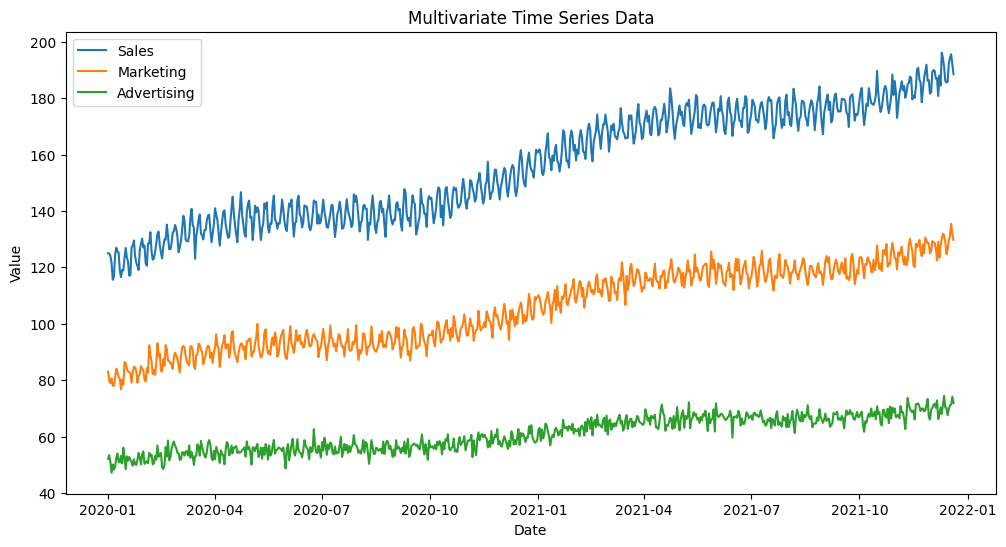

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
## Create a multivariate autoregressive sales data with 3 features: sales, marketing spend, and advertising spend to show if we can capture the relationships between past values of all three features to forecast the future values of sales. 
date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
np.random.seed(42)
doy = date_range.dayofyear.to_numpy()  # force NumPy, not pandas Index
data1 = 120 + 0.1 * np.arange(720) + 5 * np.sin(2 * np.pi * doy / 7) + 6 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)
data2 = 80 + 0.07 * np.arange(720) + 3 * np.sin(2 * np.pi * doy / 7) + 4 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)
data3 = 50 + 0.03 * np.arange(720) + 1 * np.sin(2 * np.pi * doy / 7) + 2 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)
multivariate_data = pd.DataFrame({'sales': data1, 'marketing': data2, 'advertising': data3}, index=date_range)

## add the day of week and month as categorical variables to the multivariate dataset
multivariate_data["day_of_week"] = multivariate_data.index.dayofweek
multivariate_data["month"] = multivariate_data.index.month

# plot the multivariate data
plt.figure(figsize=(12, 6))
plt.plot(multivariate_data.index, multivariate_data['sales'], label='Sales')
plt.plot(multivariate_data.index, multivariate_data['marketing'], label='Marketing')
plt.plot(multivariate_data.index, multivariate_data['advertising'], label='Advertising')
plt.title('Multivariate Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:

from peshbeen.models import var, ml_forecaster
#split the data into train and test sets 
mv_train_data = multivariate_data.iloc[:-60]
mv_test_data = multivariate_data.iloc[-60:]

var_model =var(target_cols=['sales', 'marketing', 'advertising'], lags={'sales': 7, 'marketing': 7, 'advertising': 7}, cat_variables=['day_of_week', 'month'])
var_model.fit(mv_train_data)
var_forecasts = var_model.forecast(H=60, exog=mv_test_data[['day_of_week', 'month']])

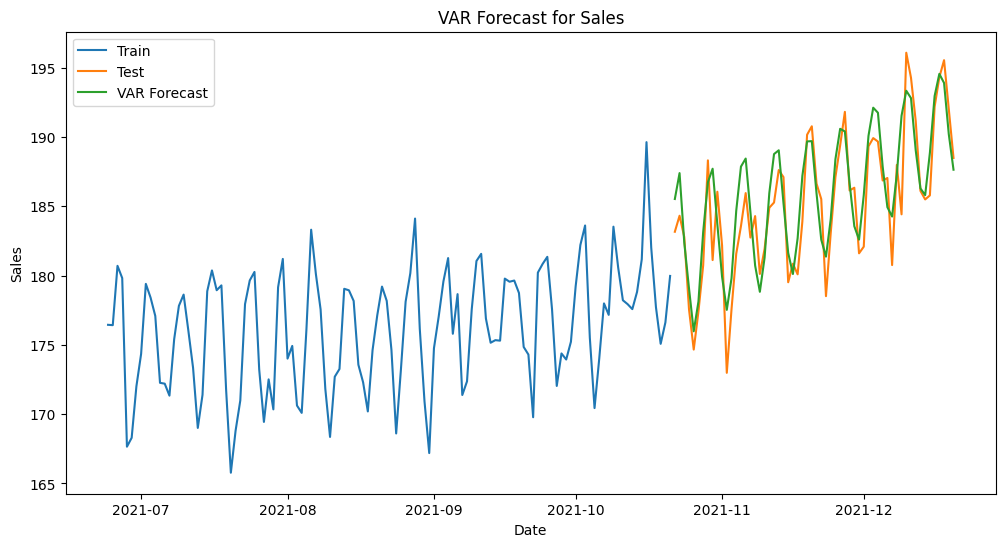

In [ ]:
# plot the forecasts and the actual values for sales
plt.figure(figsize=(12, 6))
plt.plot(mv_train_data.index[-120:], mv_train_data['sales'][-120:], label='Train')
plt.plot(mv_test_data.index, mv_test_data['sales'], label='Test')
plt.plot(mv_test_data.index, var_forecasts['sales'], label='VAR Forecast')
plt.title('VAR Forecast for Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()